In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
car = pd.read_csv('carprices.csv')
car

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [3]:
c1 = pd.get_dummies(car,['Car Model'])
c1

,Mileage,Sell Price($),Age(yrs),Car Model_Audi A5,Car Model_BMW X5,Car Model_Mercedez Benz C class
0,69000,18000,6,False,True,False
1,35000,34000,3,False,True,False
2,57000,26100,5,False,True,False
3,22500,40000,2,False,True,False
4,46000,31500,4,False,True,False
5,59000,29400,5,True,False,False
6,52000,32000,5,True,False,False
7,72000,19300,6,True,False,False
8,91000,12000,8,True,False,False
9,67000,22000,6,False,False,True


In [4]:
x = c1[['Mileage','Age(yrs)','Car Model_Audi A5','Car Model_BMW X5','Car Model_Mercedez Benz C class']]
print(x)
print(x.shape)

    Mileage  Age(yrs)  Car Model_Audi A5  Car Model_BMW X5  \
0     69000         6              False              True   
1     35000         3              False              True   
2     57000         5              False              True   
3     22500         2              False              True   
4     46000         4              False              True   
5     59000         5               True             False   
6     52000         5               True             False   
7     72000         6               True             False   
8     91000         8               True             False   
9     67000         6              False             False   
10    83000         7              False             False   
11    79000         7              False             False   
12    59000         5              False             False   

    Car Model_Mercedez Benz C class  
0                             False  
1                             False  
2                

In [5]:
y = c1['Sell Price($)']
print(y)
print(y.shape)

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64
(13,)


In [6]:
c1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Mileage                          13 non-null     int64
 1   Sell Price($)                    13 non-null     int64
 2   Age(yrs)                         13 non-null     int64
 3   Car Model_Audi A5                13 non-null     bool 
 4   Car Model_BMW X5                 13 non-null     bool 
 5   Car Model_Mercedez Benz C class  13 non-null     bool 
dtypes: bool(3), int64(3)
memory usage: 483.0 bytes


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25)

In [8]:
from sklearn.tree import DecisionTreeRegressor
mod = DecisionTreeRegressor(criterion='squared_error',max_depth=3)
mod.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
mod.score(x_test,y_test)

0.6721410992616899

In [11]:
#calculate y_pre
#draw tree using matplotlib
#calculate mse, mae



In [12]:
y_pre = mod.predict(x_test)
y_pre

array([27750., 27750., 19300., 21000.])

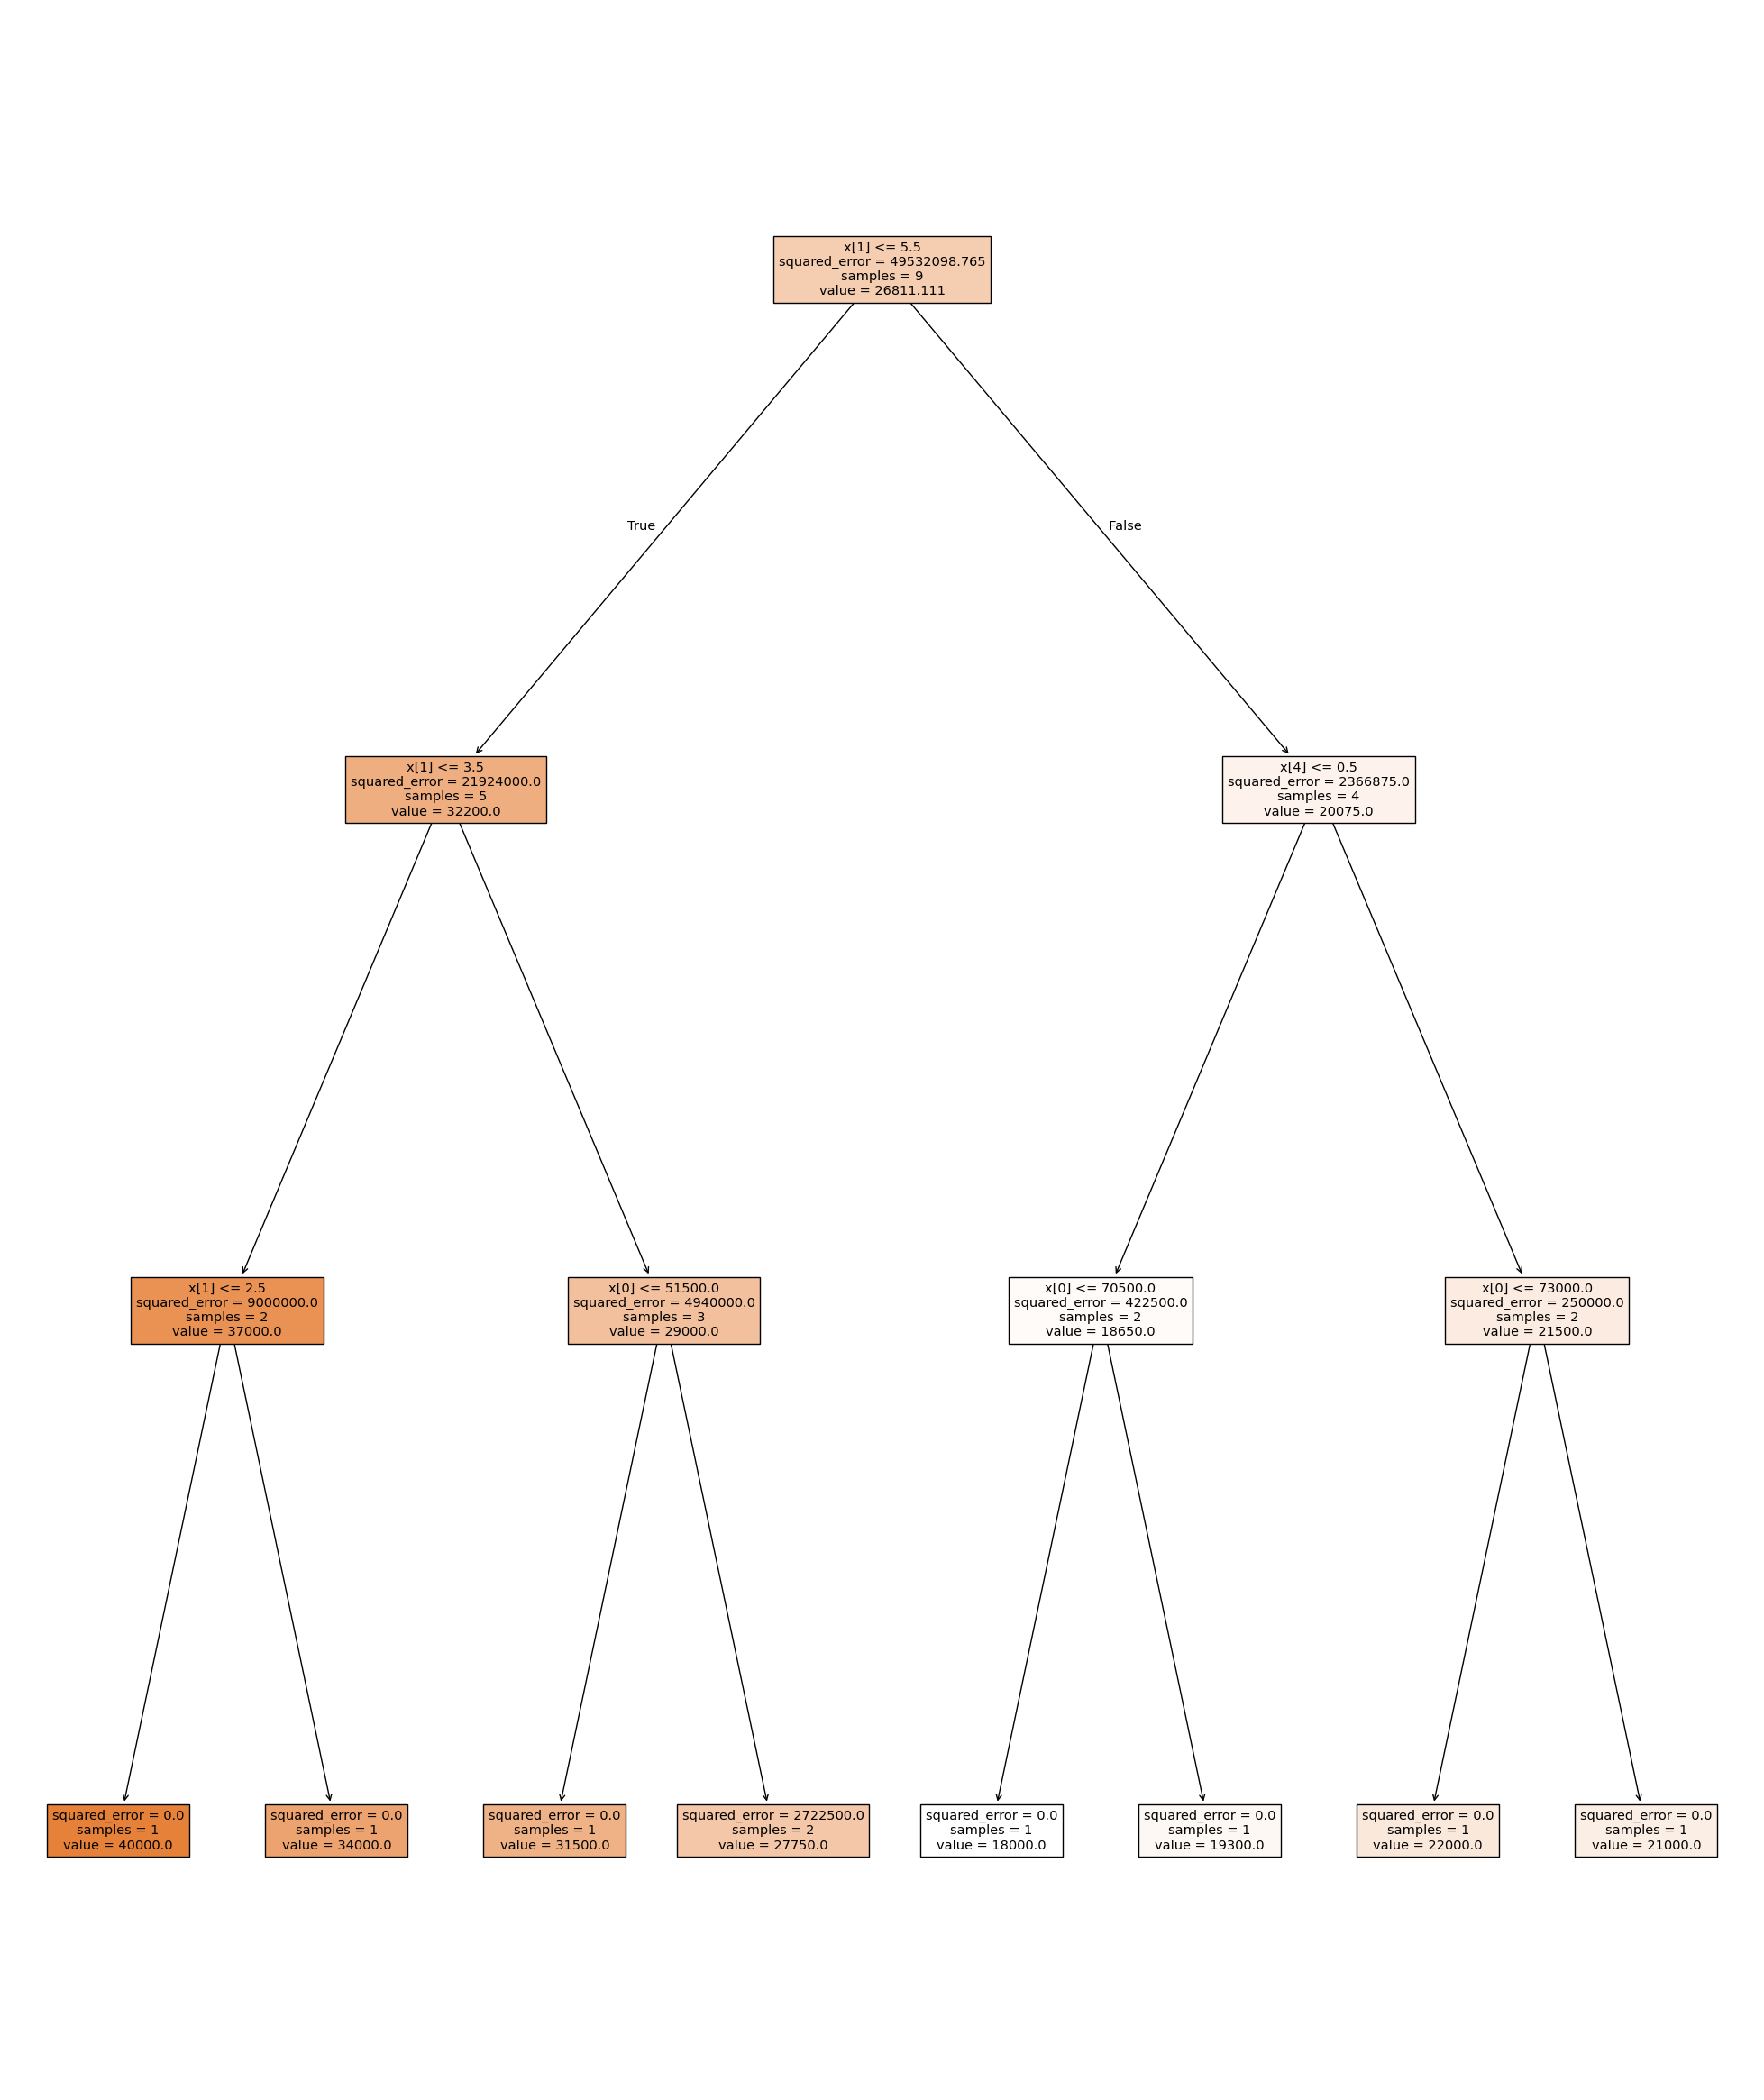

In [13]:
from sklearn import tree
fig = plt.figure(figsize=(25,30))
g=tree.plot_tree(mod,filled=True)

In [14]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test,y_pre))

24978750.0


In [15]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test,y_pre))

4450.0
